In [ ]:
# 04-01-2026

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# 1) ML Web App
# 1. Load the data
# 2. Build the ML model
# 3. Save the model => pickle, joblib

# Web App
# a. VS Code
# b. pickle file, joblib file binary file
# c. Libraries - streamlit, pandas, numpy, sklearn, pickle

# 2) Model Deployment
# AWS, Azure, GCP - Cloude Computing Platforms

# IAAs - Infrastructure as a Service
# PAAS - Platform as a Servie
# SAAS - Software as a Service



# 1) AWS Account Setup - free for 6 months

# on AWS, we will rent a server and we will upload the
# files (pickle file, app.py, requirements.txt file)
# EC2 = Elastic Cloude Compute *(Free Tier)

In [ ]:
# file is accessed using upload to session option
df = pd.read_csv('/content/me_cfs_vs_depression.csv')

In [ ]:
df.head()

,age,gender,sleep_quality_index,brain_fog_level,physical_pain_score,stress_level,depression_phq9_score,fatigue_severity_scale_score,pem_duration_hours,hours_of_sleep_per_night,pem_present,work_status,social_activity_level,exercise_frequency,meditation_or_mindfulness,diagnosis
0,56,Male,8.7,3.9,9.2,8.1,10.0,6.5,9.0,7.7,0,Working,Low,Daily,Yes,Depression
1,69,Male,1.3,9.9,4.2,9.9,20.0,7.0,41.0,8.4,1,Working,Low,Often,Yes,Both
2,46,Female,4.0,5.4,4.8,NaN,24.0,1.6,13.0,6.9,0,Partially working,NaN,Rarely,Yes,Depression
3,32,Female,9.4,2.1,2.9,3.8,10.0,6.8,11.0,7.5,0,Not working,High,Never,Yes,Depression
4,60,Female,7.6,7.5,6.4,8.5,17.0,7.0,46.0,3.1,1,Not working,Low,Rarely,No,Both


In [ ]:
df.shape

(1000, 16)

In [ ]:
df.dtypes

,0
age,int64
gender,object
sleep_quality_index,float64
brain_fog_level,float64
physical_pain_score,float64
stress_level,float64
depression_phq9_score,float64
fatigue_severity_scale_score,float64
pem_duration_hours,float64
hours_of_sleep_per_night,float64


In [ ]:
df.isnull().sum()

,0
age,0
gender,0
sleep_quality_index,47
brain_fog_level,48
physical_pain_score,34
stress_level,48
depression_phq9_score,22
fatigue_severity_scale_score,21
pem_duration_hours,24
hours_of_sleep_per_night,21


In [ ]:
num_null = [i for i in df.columns if df[i].dtypes!='object' and df[i].isnull().sum()>0]
print(num_null)
cat_null = [i for i in df.columns if df[i].dtypes=='object' and df[i].isnull().sum()>0]
print(cat_null)

['sleep_quality_index', 'brain_fog_level', 'physical_pain_score', 'stress_level', 'depression_phq9_score', 'fatigue_severity_scale_score', 'pem_duration_hours', 'hours_of_sleep_per_night']
['work_status', 'social_activity_level', 'exercise_frequency', 'meditation_or_mindfulness']


In [ ]:
for i in num_null:
  df[i] = df[i].fillna(df[i].mean())

In [ ]:
for i in cat_null:
  print(i, df[i].value_counts())

work_status work_status
Partially working    335
Working              320
Not working          298
Name: count, dtype: int64
social_activity_level social_activity_level
Very low     203
High         200
Low          190
Very high    186
Medium       181
Name: count, dtype: int64
exercise_frequency exercise_frequency
Rarely       210
Often        202
Daily        194
Sometimes    184
Never        171
Name: count, dtype: int64
meditation_or_mindfulness meditation_or_mindfulness
Yes    505
No     484
Name: count, dtype: int64


In [ ]:
# there is no much diff bet values so we can not use mode (most repeated value)
# another way

In [ ]:
# Proportionate Filling

In [ ]:
df['work_status'].value_counts(normalize=True)

,proportion
work_status,
Partially working,0.351522
Working,0.335782
Not working,0.312697


In [ ]:
# we will fill all 3 above values in 47 nulls with proportion of 0.35, 0.335, 0.315

In [ ]:
ws_fv = np.random.choice(['Partially working','Working','Not working'], size=47, p=[0.35,0.335,0.315])
# print(ws_fv)

In [ ]:
ws_nv_idx = df[df['work_status'].isnull()].index
print(len(ws_nv_idx))

47


In [ ]:
df.loc[ws_nv_idx, 'work_status'] = ws_fv

In [ ]:
# for saving time doing remaining with mode

In [ ]:
for i in ['social_activity_level', 'exercise_frequency', 'meditation_or_mindfulness']:
  df[i] = df[i].fillna(df[i].mode()[0])

In [ ]:
df.isnull().sum()

,0
age,0
gender,0
sleep_quality_index,0
brain_fog_level,0
physical_pain_score,0
stress_level,0
depression_phq9_score,0
fatigue_severity_scale_score,0
pem_duration_hours,0
hours_of_sleep_per_night,0


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.columns

Index(['age', 'gender', 'sleep_quality_index', 'brain_fog_level',
       'physical_pain_score', 'stress_level', 'depression_phq9_score',
       'fatigue_severity_scale_score', 'pem_duration_hours',
       'hours_of_sleep_per_night', 'pem_present', 'work_status',
       'social_activity_level', 'exercise_frequency',
       'meditation_or_mindfulness', 'diagnosis'],
      dtype='object')

In [ ]:
num_cols = df.dtypes[df.dtypes!='object'].index
cat_cols = df.dtypes[df.dtypes=='object'].index
print(cat_cols)
print(cat_cols)

Index(['gender', 'work_status', 'social_activity_level', 'exercise_frequency',
       'meditation_or_mindfulness', 'diagnosis'],
      dtype='object')
Index(['gender', 'work_status', 'social_activity_level', 'exercise_frequency',
       'meditation_or_mindfulness', 'diagnosis'],
      dtype='object')


In [ ]:
# Univeriate Analysis - Countplot

In [ ]:
cols = cat_cols
plt.figure(figsize=(14,15))
for i in range(len(cols)):
  plt.subplot(3,2,i+1)  # (rows = 3, cols= 2)
  ax = sns.countplot(x=df[cols[i]])
  ax.bar_label(ax.containers[0])
  plt.title(f'Countplot for {cols[i]}')
plt.show()

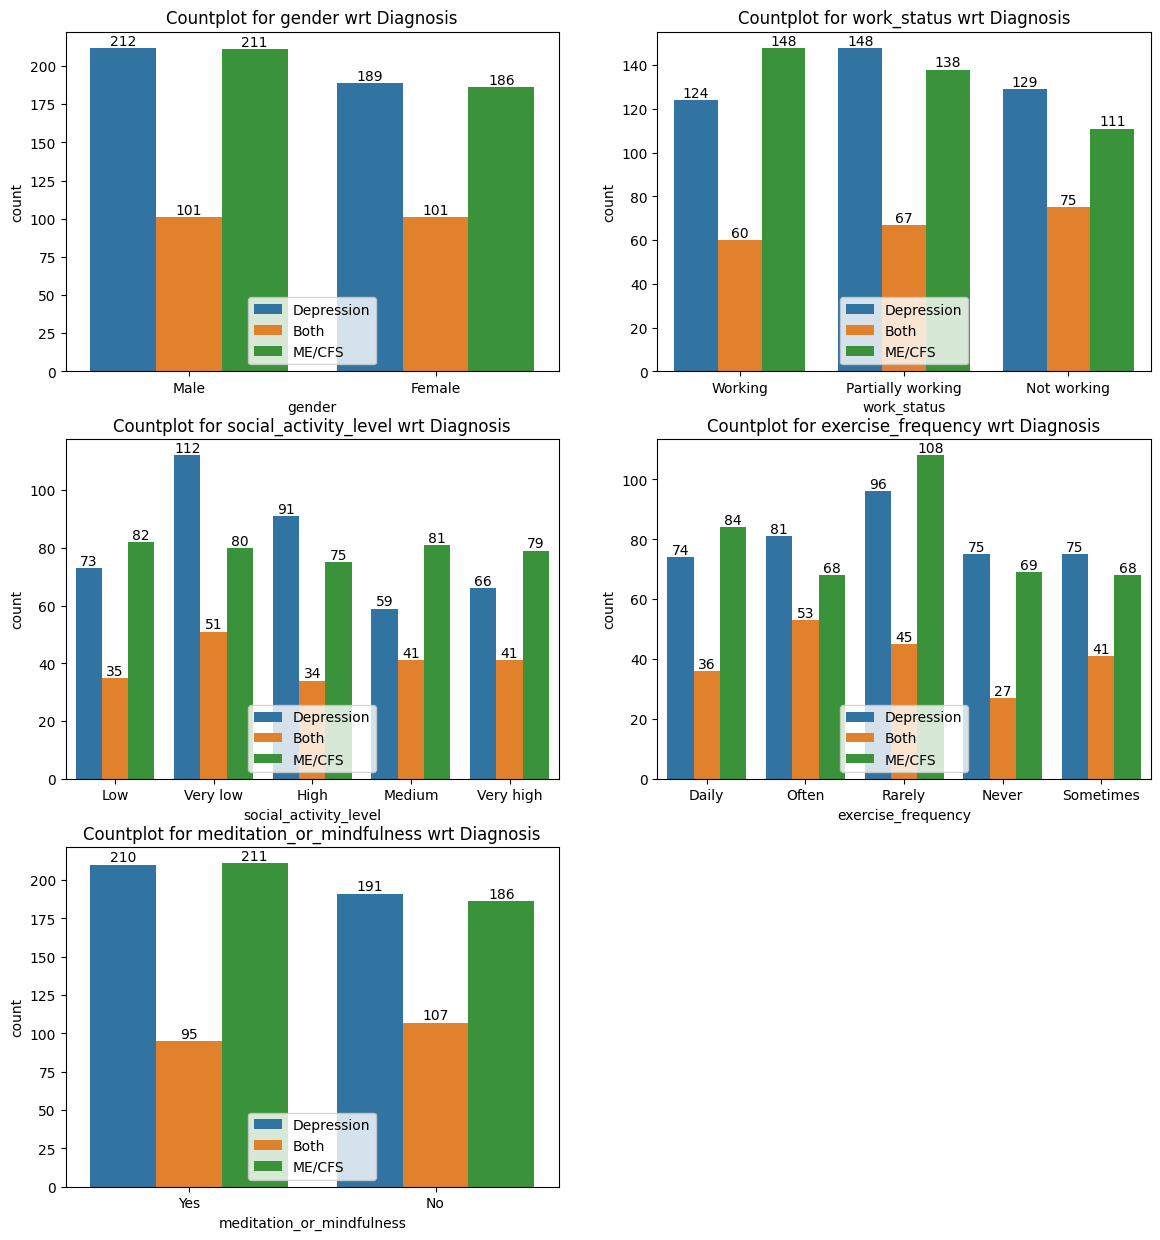

In [ ]:
cols = cat_cols[:-1]
plt.figure(figsize=(14,15))
for i in range(len(cols)):
  plt.subplot(3,2,i+1)
  ax= sns.countplot(x=df[cols[i]], hue=df['diagnosis'])
  ax.bar_label(ax.containers[0])
  ax.bar_label(ax.containers[1])
  ax.bar_label(ax.containers[2])
  plt.title(f'Countplot for {cols[i]} wrt Diagnosis')
  plt.legend(loc=8)
plt.show()


In [ ]:
# Univariate Analysis - Numerical Cols

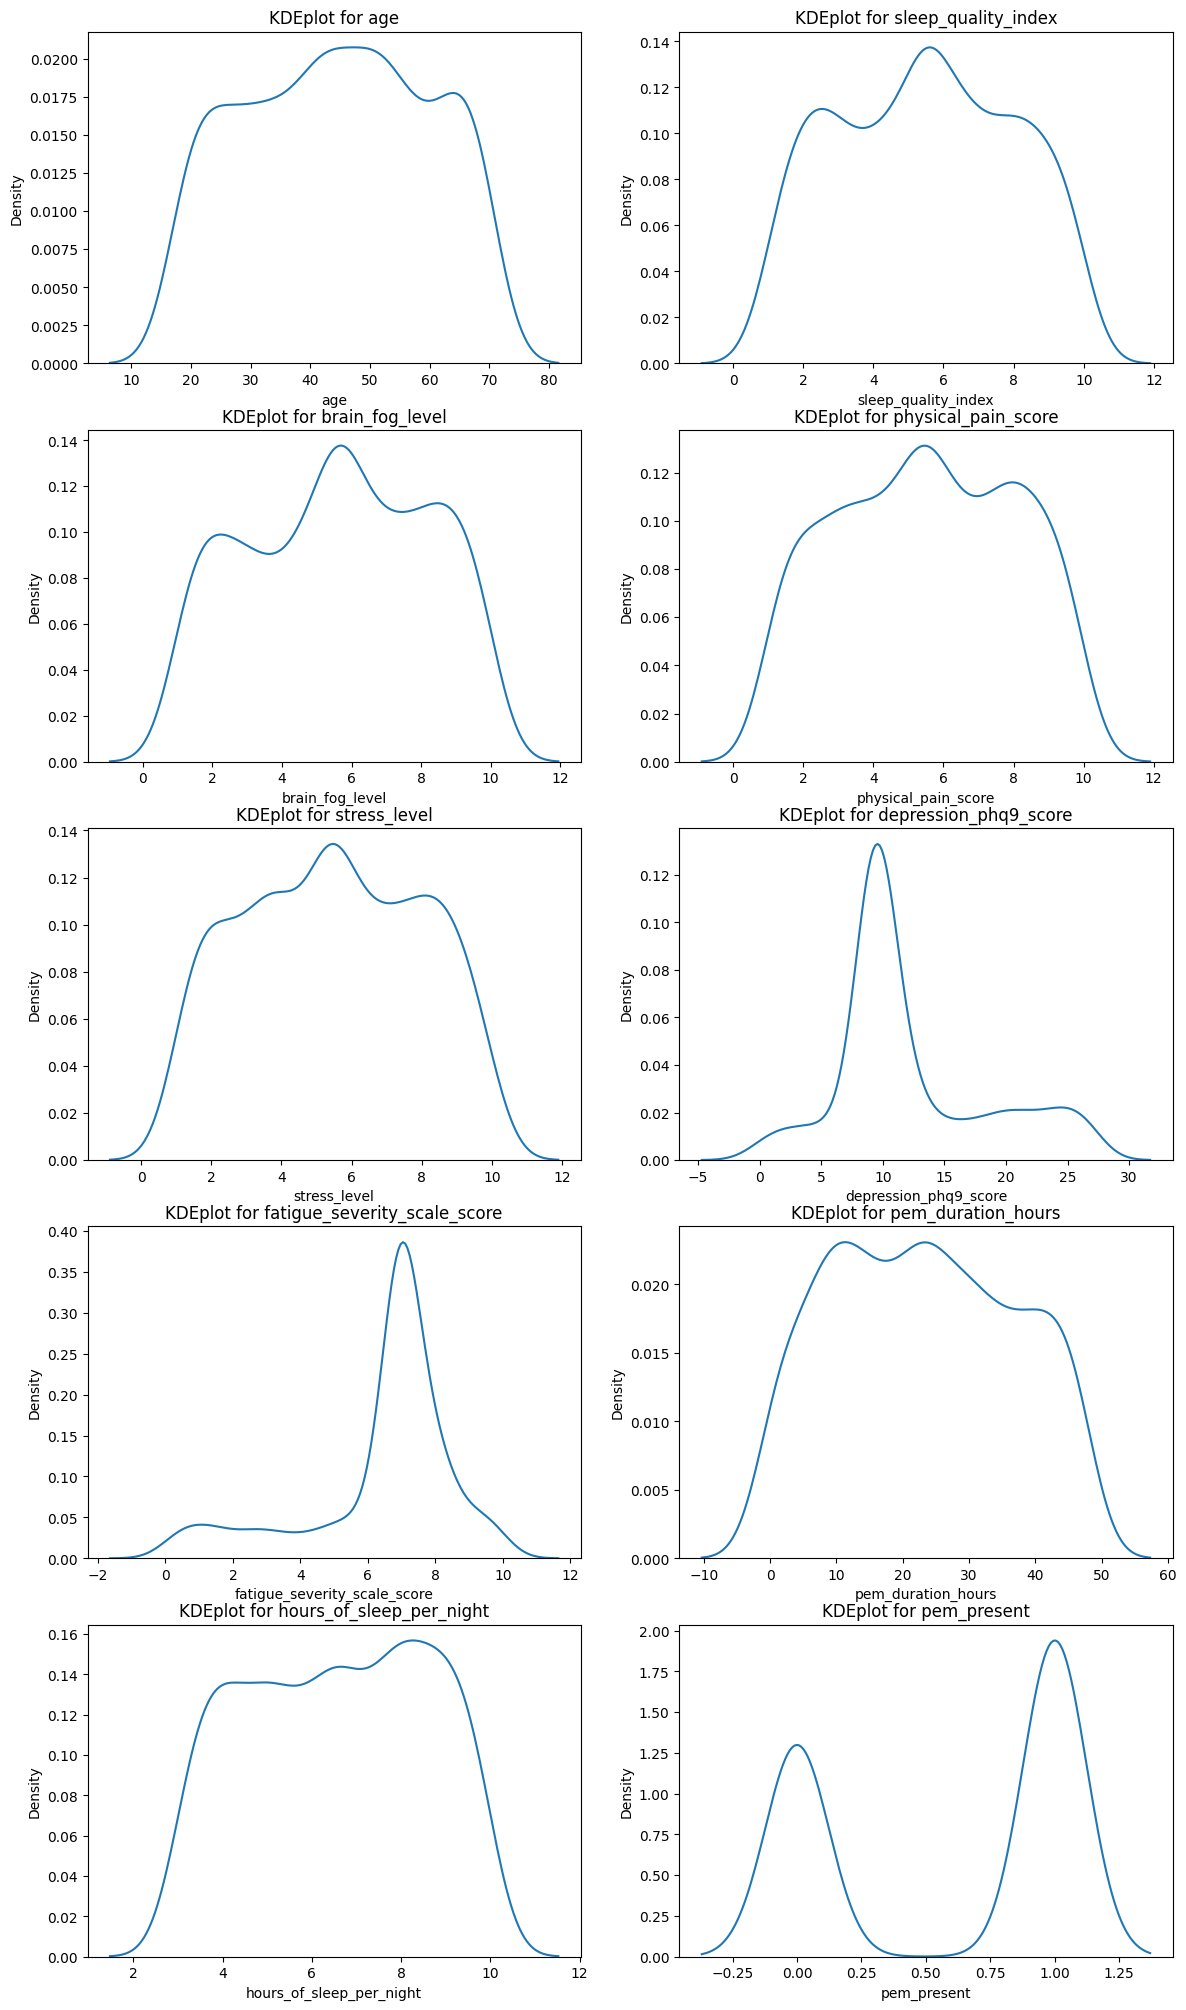

In [ ]:
cols = num_cols

plt.figure(figsize=(14,25))  # width=14, height = 25

for i in range(len(cols)):

  plt.subplot(5,2,i+1)  # (rows = 5, cols= 2)

  sns.kdeplot(x=df[cols[i]])   # data distribution

  plt.title(f'KDEplot for {cols[i]}')

plt.show()

In [ ]:
# Corr

In [ ]:
num_cols

Index(['age', 'sleep_quality_index', 'brain_fog_level', 'physical_pain_score',
       'stress_level', 'depression_phq9_score', 'fatigue_severity_scale_score',
       'pem_duration_hours', 'hours_of_sleep_per_night', 'pem_present'],
      dtype='object')

In [ ]:
corr = df[num_cols].corr()

plt.figure(figsize=(8,8))
sns.heatmap(corr,annot=True,cmap='coolwarm')
plt.show()

In [ ]:
# Outliers Treatment

In [ ]:
# Detect Outliers
# df[num_cols] = df[num_cols].clip(lower=df[num_cols].quantile(0.05), upper=df[num_cols].quantile(0.95))

a1 = df[num_cols].describe(percentiles=[0.01,0.02,0.03,0.05,0.95,0.97,0.98,0.99]).T
a1 = a1.iloc[:,3:]
a1

,min,1%,2%,3%,5%,50%,95%,97%,98%,99%,max
age,18.0,18.00,18.000,19.000,20.0,45.000000,68.000,69.000,70.000,70.0,70.0
sleep_quality_index,1.0,1.10,1.200,1.300,1.5,5.468625,9.500,9.700,9.800,9.9,10.0
brain_fog_level,1.0,1.10,1.198,1.300,1.4,5.611765,9.600,9.800,9.802,9.9,10.0
physical_pain_score,1.0,1.10,1.100,1.200,1.4,5.521843,9.500,9.603,9.800,9.9,10.0
stress_level,1.0,1.10,1.200,1.297,1.5,5.459139,9.400,9.700,9.800,9.9,10.0
depression_phq9_score,0.0,0.99,1.000,2.000,3.0,10.000000,25.000,26.000,26.000,27.0,27.0
fatigue_severity_scale_score,0.0,0.30,0.500,0.700,1.1,7.000000,9.200,9.500,9.700,9.8,10.0
pem_duration_hours,0.0,0.00,0.000,1.000,2.0,23.000000,46.000,46.000,47.000,47.0,47.0
hours_of_sleep_per_night,3.0,3.10,3.100,3.200,3.3,6.585649,9.605,9.800,9.900,9.9,10.0
pem_present,0.0,0.00,0.000,0.000,0.0,1.000000,1.000,1.000,1.000,1.0,1.0


In [ ]:
df['fatigue_severity_scale_score'] = np.where(df['fatigue_severity_scale_score'] <0.30 	,0.30
                                              ,df['fatigue_severity_scale_score'])

In [ ]:
a1 = df[num_cols].describe(percentiles=[0.01,0.02,0.03,0.05,0.95,0.97,0.98,0.99]).T
a1 = a1.iloc[:,3:]
a1

In [ ]:
# encoding

In [ ]:
for i in cat_cols:
  print(i,df[i].unique())

gender ['Male' 'Female']
work_status ['Working' 'Partially working' 'Not working']
social_activity_level ['Low' 'Very low' 'High' 'Medium' 'Very high']
exercise_frequency ['Daily' 'Often' 'Rarely' 'Never' 'Sometimes']
meditation_or_mindfulness ['Yes' 'No']
diagnosis ['Depression' 'Both' 'ME/CFS']


In [ ]:
df['gender'] = df['gender'].replace({'Male':1,'Female':0})
df['meditation_or_mindfulness'] = df['meditation_or_mindfulness'].replace({'Yes':1,'No':0})

/tmp/ipython-input-850373332.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['gender'] = df['gender'].replace({'Male':1,'Female':0})
/tmp/ipython-input-850373332.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['meditation_or_mindfulness'] = df['meditation_or_mindfulness'].replace({'Yes':1,'No':0})


In [ ]:
df.shape

(1000, 16)

In [ ]:
df_dummies = pd.get_dummies(data=df,columns=['work_status','social_activity_level',
                                             'exercise_frequency'],dtype=int,drop_first=True)
print(df_dummies.shape)
print(df_dummies.columns)

(1000, 23)

In [ ]:
df_dummies.head()

In [ ]:
df_dummies.dtypes

,0
age,int64
gender,int64
sleep_quality_index,float64
brain_fog_level,float64
physical_pain_score,float64
stress_level,float64
depression_phq9_score,float64
fatigue_severity_scale_score,float64
pem_duration_hours,float64
hours_of_sleep_per_night,float64


In [ ]:
# select x & y

In [ ]:
x = df_dummies.drop('diagnosis',axis=1)
y = df_dummies['diagnosis']

print(x.shape)
print(y.shape)

(1000, 22)
(1000,)


In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
x_train, x_test, y_train, y_test = train_test_split(x,y, test_size=0.3, random_state=42)
print(x_train.shape)
print(x_test.shape)

(700, 22)
(300, 22)


In [ ]:
# Model Building

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC

In [ ]:
from sklearn.metrics import *

In [ ]:
def eval_model(ytest,ypred):
  cm = confusion_matrix(ytest,ypred)
  crep = classification_report(ytest,ypred)
  print(cm)
  print(crep)

In [ ]:
# Log Reg
lr = LogisticRegression(max_iter=10000)
lr.fit(x_train,y_train)
ypred_lr = lr.predict(x_test)
eval_model(y_test,ypred_lr)

[[ 45   0   9]
 [  0 125   0]
 [  1   0 120]]
              precision    recall  f1-score   support

        Both       0.98      0.83      0.90        54
  Depression       1.00      1.00      1.00       125
      ME/CFS       0.93      0.99      0.96       121

    accuracy                           0.97       300
   macro avg       0.97      0.94      0.95       300
weighted avg       0.97      0.97      0.97       300



/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [ ]:
# for overfitting
print('Train_Score', lr.score(x_train, y_train))
print('Test_Score', lr.score(x_test, y_test))

Train_Score 0.9714285714285714
Test_Score 0.9666666666666667


In [ ]:
# DT
dt = DecisionTreeClassifier(criterion='gini', max_depth=6, min_samples_split=10)
dt.fit(x_train,y_train)
ypred_dt = dt.predict(x_test)
eval_model(y_test,ypred_dt)

[[ 53   0   1]
 [  0 125   0]
 [  0   0 121]]
              precision    recall  f1-score   support

        Both       1.00      0.98      0.99        54
  Depression       1.00      1.00      1.00       125
      ME/CFS       0.99      1.00      1.00       121

    accuracy                           1.00       300
   macro avg       1.00      0.99      1.00       300
weighted avg       1.00      1.00      1.00       300



In [ ]:
# for overfitting
print('Train_Score', dt.score(x_train, y_train))
print('Test_Score', dt.score(x_test, y_test))

Train_Score 0.9971428571428571
Test_Score 0.9966666666666667


In [ ]:
# RF
rf = RandomForestClassifier(n_estimators=90, max_depth=6, min_samples_split=10)
rf.fit(x_train,y_train)
ypred_rf = rf.predict(x_test)
eval_model(y_test,ypred_rf)

[[ 54   0   0]
 [  0 125   0]
 [  1   0 120]]
              precision    recall  f1-score   support

        Both       0.98      1.00      0.99        54
  Depression       1.00      1.00      1.00       125
      ME/CFS       1.00      0.99      1.00       121

    accuracy                           1.00       300
   macro avg       0.99      1.00      1.00       300
weighted avg       1.00      1.00      1.00       300



In [ ]:
# for overfitting
print('Train_Score', rf.score(x_train, y_train))
print('Test_Score', rf.score(x_test, y_test))

Train_Score 0.99
Test_Score 0.9966666666666667


In [ ]:
# Feature Importance

In [ ]:
fimp = pd.DataFrame({'Feature':x_train.columns,'FImp':rf.feature_importances_})
fimp = fimp.sort_values('FImp',ascending=False)
fimp

,Feature,FImp
10,pem_present,0.407924
6,depression_phq9_score,0.368434
7,fatigue_severity_scale_score,0.129768
2,sleep_quality_index,0.013721
0,age,0.012393
9,hours_of_sleep_per_night,0.011878
5,stress_level,0.010335
3,brain_fog_level,0.009524
8,pem_duration_hours,0.008903
4,physical_pain_score,0.008729


In [ ]:
# save the model

In [ ]:
import pickle

In [ ]:
pickle.dump(rf, open('/content/drive/MyDrive/ML Deployement/rf.pkl', 'wb'))
pickle.dump(dt, open('/content/drive/MyDrive/ML Deployement/dt.pkl', 'wb'))
pickle.dump(lr, open('/content/drive/MyDrive/ML Deployement/lr.pkl', 'wb'))

In [ ]:
y_train.value_counts()

,count
diagnosis,
ME/CFS,276
Depression,276
Both,148
